# Regression analysis (Energy and position)

## First run - sc4422

### Parameters
wcte_regression.yaml

Overrides: 

data.dataset.transforms=['double_cover'] model.conv_pad_mode='circular' \
tasks.train.data_loaders.train.batch_size=1024 \
tasks.evaluate.data_loaders.test.batch_size=2048 \
tasks.train.data_loaders.validation.batch_size=2048 \
tasks.train.data_loaders.train.pre_transforms=[]


### Data/ Paths
data.split_path='/vols/hyperk/WCTE/ML_2025/cds_geometry/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz' \
data.dataset.geometry_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/geometries/WCTE_geometry_v1.12.21.npz' \
data.dataset.mpmt_positions_file='/vols/hyperk/WCTE/ML_2025/cds_geometry/mpmt_pos_files/WCTE_mpmt_position_correct_251125.npz' \
data.dataset.h5file='/vols/hyperk/WCTE/ML_2025/cds_geometry/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5'

### Disclaimer
New data (fixed FC and fixed mu) had 2 extra events than fitqun, causing some errors when separating out fitqun events to compare with the test outputs of the ML model. This was fixed using a different function / handling of the fitqun events (the missing indices section - using the event labels of h5 for the true labels of fitqun) -- old code assumed that h5 files were a subset of fitqun. The two events would have been removed in the physics cuts later on anyway, so should be fine, but should double check in case of any misalignment.

Direction still running but is on hold.

### Outputs
Run directory: /vols/hyperk/users/sc4422/first_run/outputs/regression/$DATE

### WatChMaL github version
workshop_2025-91-g158c799

# Setup

In [ ]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-91-g158c799


# Processing h5 data

In [7]:
cds_geo_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry'

In [8]:
idxs_path_new_geo = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz"
test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

In [9]:
data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

In [10]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [11]:
data_new_geo = get_values(h5_file_new_geo, test_idxs_new_geo)

# Processing fitQun data

In [12]:
def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
    N = len(all_event_ids)
    cut_start_idxs: list[int] = [0]
    CUTOFF = 500
    for i in range(N - 1):
        if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
            cut_start_idxs.append(i+ 1)
    cut_start_idxs.append(len(all_event_ids)-1)
    return cut_start_idxs

def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
    missing_ids_fq = []
    missing_inds_fq = []
    missing_ids_h5 = []    
    missing_inds_h5 = []
    n_cuts = len(fq_cuts)
    assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
    for i in range(1, n_cuts):
        fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
        h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

        fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
        h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

        assert fq_ids[0] < 100
        assert fq_ids[-1] > 990

        missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
        if len(missing_both) > 0:
            print(missing_both)

        missing_fq = np.setdiff1d(fq_ids, h5_ids)
        inds_fq = np.searchsorted(fq_ids, missing_fq)

        missing_ids_fq.append(missing_fq.tolist())
        missing_inds_fq.append(fq_start_idx + inds_fq)


        missing_h5 = np.setdiff1d(h5_ids, fq_ids)
        inds_h5 = np.searchsorted(h5_ids, missing_h5)

        missing_ids_h5.append(missing_h5.tolist())
        missing_inds_h5.append(h5_start_idx + inds_h5)
    
    return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [13]:
fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
fq = FiTQunOutput(fitqun_files_full)

In [14]:
#Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
fq_event_ids = fq.chain['nevt'] #.compute()
fq_event_ids =  ak.to_numpy(fq_event_ids) -1
h5_event_ids = data_new_geo['event_ids']

fq_cuts = get_cut_start_idxs(fq_event_ids)
h5_cuts = get_cut_start_idxs(h5_event_ids)
missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
print('The number of extra fq indices is:', len(missing_indices_fq))
print('The number of extra h5 indices is:', len(missing_indices_h5))

The difference between fitqun and h5 event ids is: 61041
The number of extra fq indices is: 61043
The number of extra h5 indices is: 2


In [15]:
fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
h5_keep_idx = np.delete(np.arange(len(data_new_geo['event_ids'])), missing_indices_h5)

fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==2]
fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==1]
fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [16]:
h5_electron_flag = fq.electron_flag
h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
h5_muon_flag = fq.muon_flag#.compute()
h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

fc_cut = data_new_geo['fc'][h5_keep_idx]
mu_cut = data_new_geo['labels'][h5_keep_idx]==2
el_cut = data_new_geo['labels'][h5_keep_idx]==1

reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [17]:
mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
fq_mu_nll = mu_mu - el_mu
fq_el_nll = mu_el - el_el

# Making cuts and extracting data

In [18]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [19]:
def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25
    energies_cut = data['energies'] > 800

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

cuts_new_geo = apply_cuts(data_new_geo)

In [20]:
e_idxs_new_geo = data_new_geo['labels']==1
mu_idxs_new_geo = data_new_geo['labels']==2

In [21]:
def get_particle_quantities(data, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    particle_mask = data['labels'] == particle_type

    labels = data['labels'][particle_mask]
    momentum = data['momentum'][particle_mask]
    positions = data['positions'][particle_mask]
    directions = data['directions'][particle_mask]
    angles = data['angles'][particle_mask]
    dwall = data['dwall'][particle_mask]
    towall = data['towall'][particle_mask]
    cuts_selected = cuts[particle_mask] if cuts is not None else None
    indices = cuts[particle_mask]

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

In [22]:
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo, 1, cuts_new_geo)
mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo, 2, cuts_new_geo)

# should replace this with the method below / other way around

In [23]:
resnet_args = {'linestyle':"-"}
electron_args_new_geo = {'indices':test_idxs_new_geo[e_idxs_new_geo], 'selection':e_cuts}
muon_args_new_geo = {'indices':test_idxs_new_geo[mu_idxs_new_geo],'selection':mu_cuts}

# Loading ResNet results

In [24]:
outdir_reg = "/vols/hyperk/users/sc4422/first_run/outputs/regression/"

In [25]:
output_energy = "2026-02-05/18-30-30"
output_pos = "2026-02-05/21-17-54"
output_dir = ""

resnet_muon_position = [
    WatChMaLPositionRegression(outdir_reg+output_pos, "ResNet50 QT+mPMT_pos", mu_pos, mu_dir, **muon_args_new_geo, **resnet_args)
]
# resnet_muon_direction = [
# ]
resnet_muon_energy = [
    WatChMaLEnergyRegression(outdir_reg+output_energy, "QT+mPMT_pos decay", mu_mom, 2, **muon_args_new_geo, **resnet_args)
]


/vols/hyperk/users/sc4422/first_run/WatChMaL/watchmal/utils/math.py:95: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(energy**2 - mass**2)


# Plot training progression

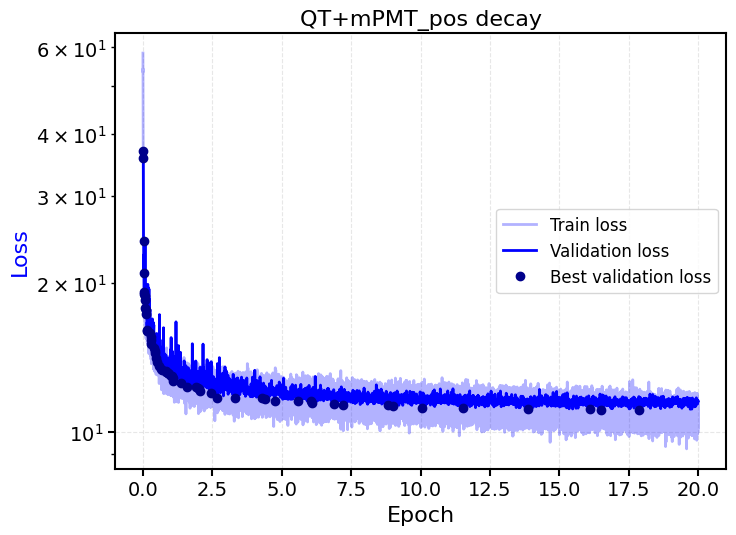

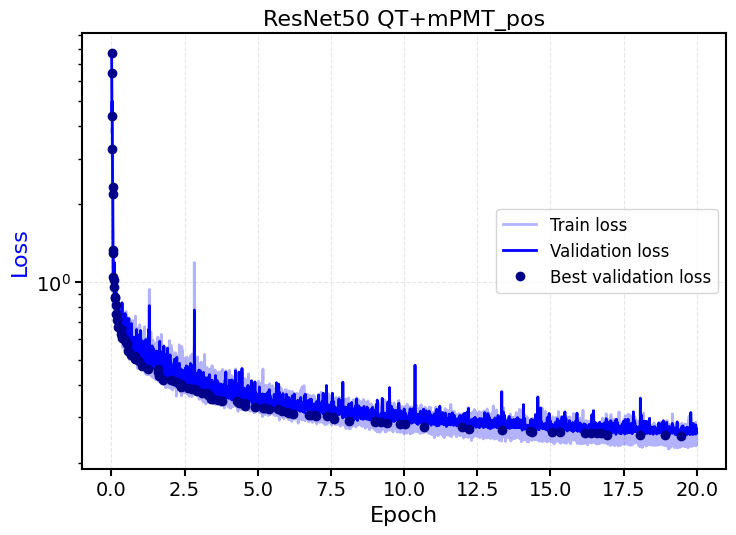

In [26]:
for r in resnet_muon_energy:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')
    # ax1.set_ylim(0.1, 100)
    # ax1.set_xlim(10,)
# for r in resnet_muon_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_electron_position:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_electron_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_electron_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
for r in resnet_muon_position:
    fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
    # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
    ax1.set_yscale('log')

# Energy and position statistics

In [27]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']
tabulate_statistics(resnet_muon_position, position_stats, position_stat_labels, position_stat_types)

,ResNet50 QT+mPMT_pos
x position resolution [cm],3.32
y position resolution [cm],3.36
z position resolution [cm],3.31
3D position resolution [cm],6.36
Transverse position resolution [cm],5.31
Longitudinal position resolution [cm],2.95
Longitudinal position mean bias [cm],0.26


In [28]:
energy_stats = ["momentum_fractional_errors", "momentum_residuals"]
energy_stat_labels = ["Momentum fractional error resolution", "Momentum residual resolution"]
energy_stat_types = ['resolution', 'resolution']
tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)

# infinite values causing nan -- need to fix

,QT+mPMT_pos decay
Momentum fractional error resolution,nan
Momentum residual resolution,nan


# Energy and position plots

In [41]:
print(len(data_new_geo["positions"][h5_keep_idx][mu_mask_h5]))
print(len(mu_pos[mu_cuts]))

# A = test_idxs_new_geo[h5_keep_idx][mu_mask_h5]
# B = test_idxs_new_geo[mu_idxs_new_geo][mu_cuts]

# print(len(A), len(B))
# print(np.array_equal(A, B))                 # identical set + order
# print(np.array_equal(np.sort(A), np.sort(B)))  # identical set ignoring order


256770
256770
256770 256770
True
True


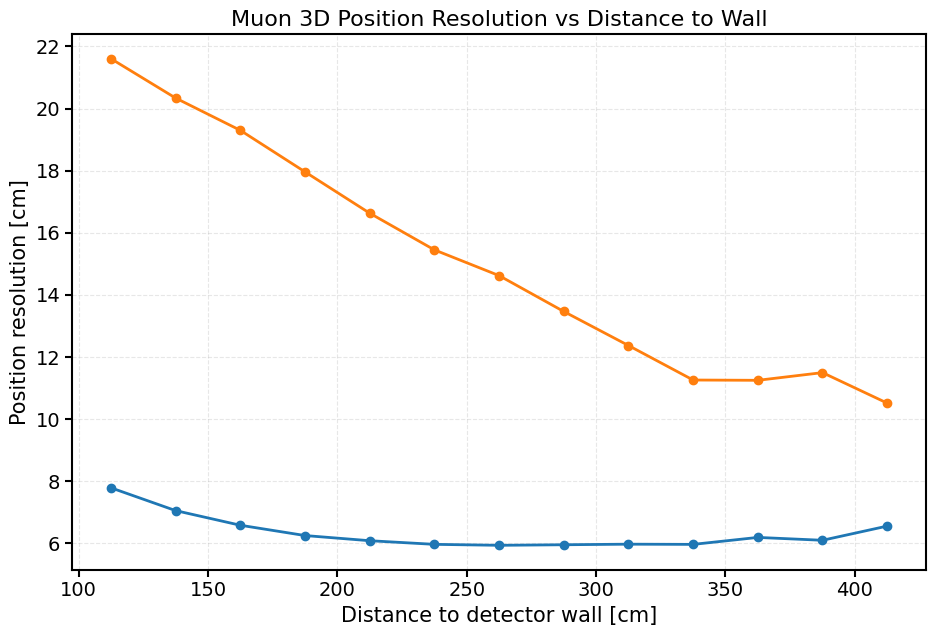

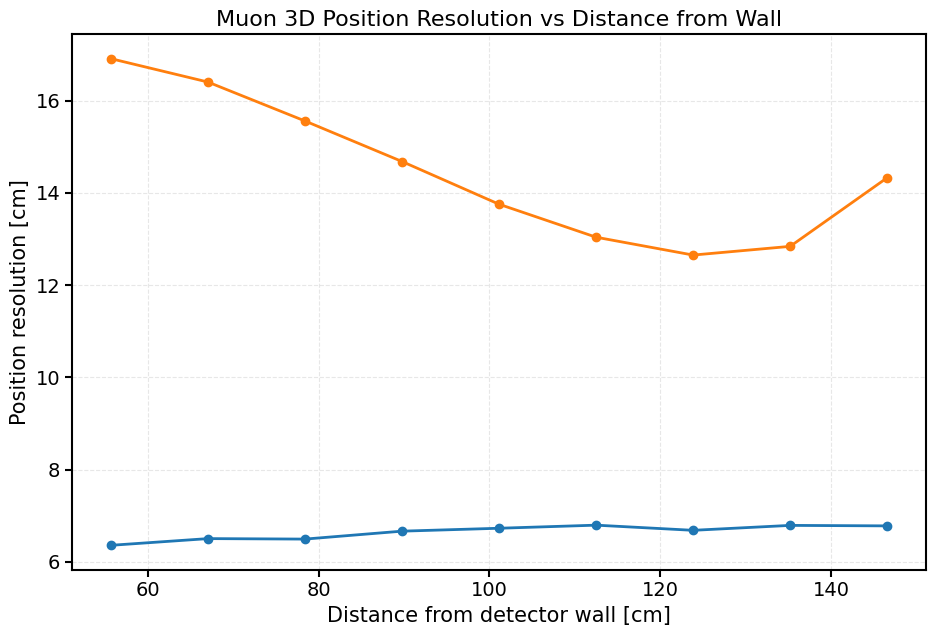

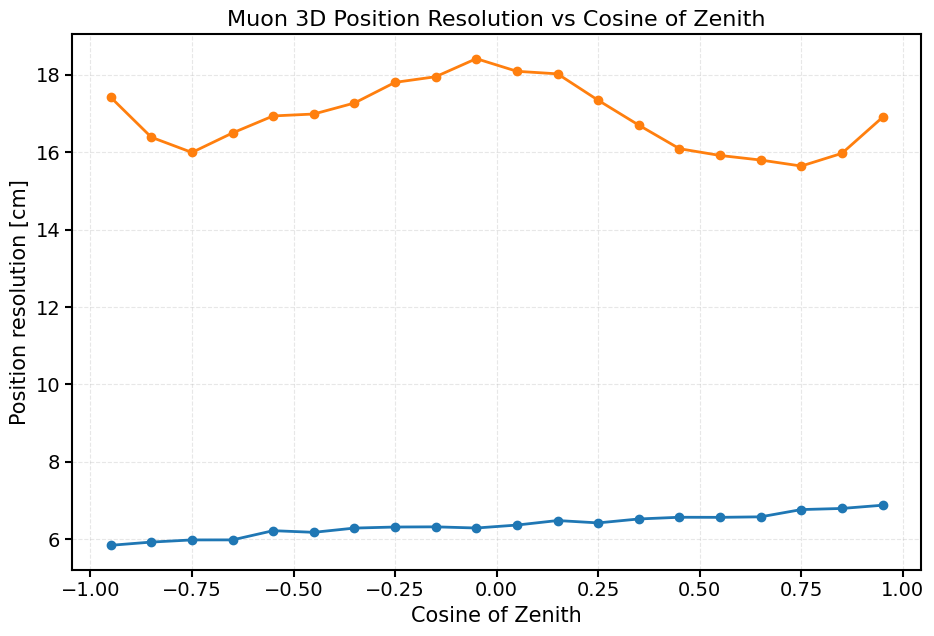

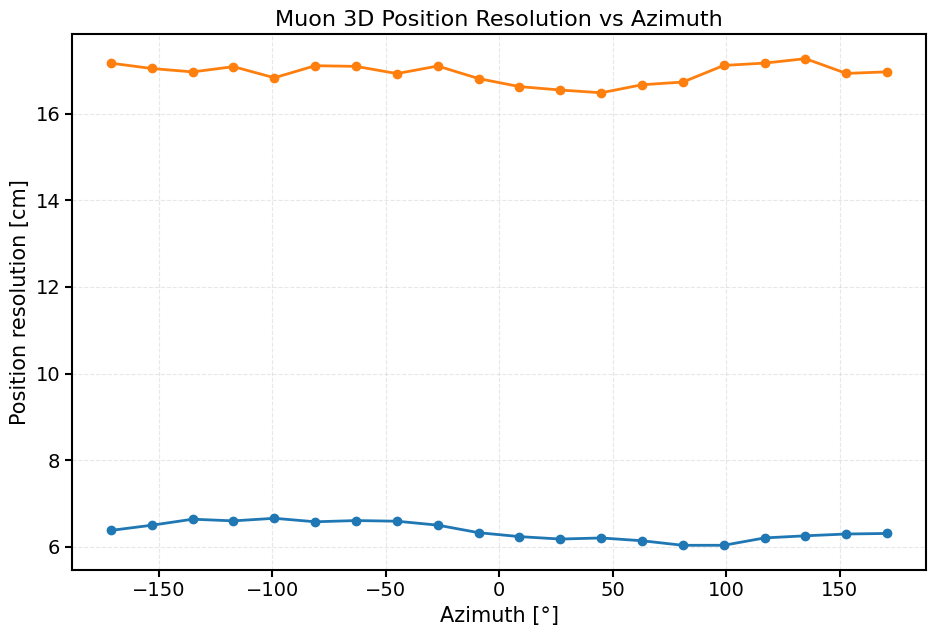

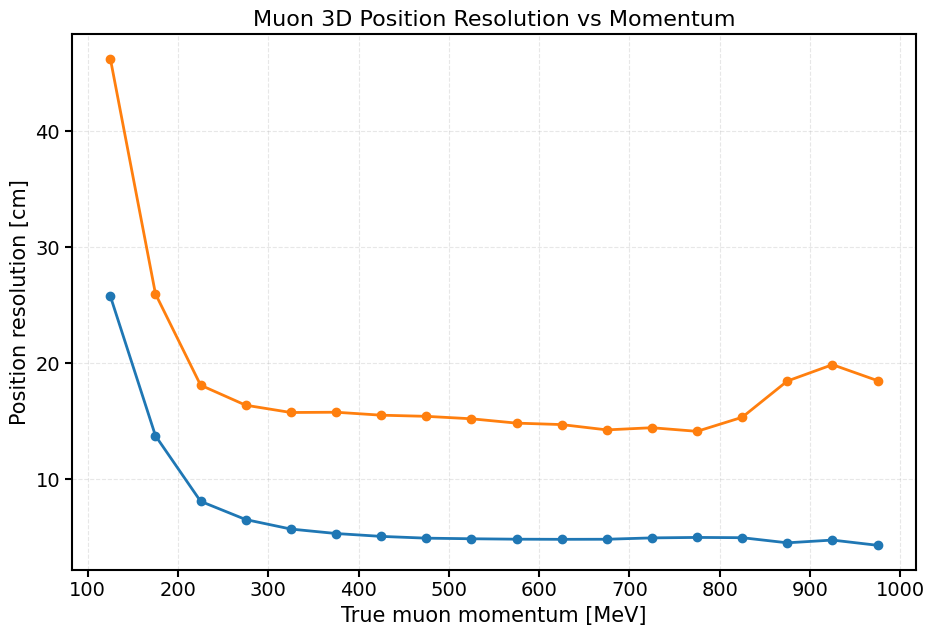

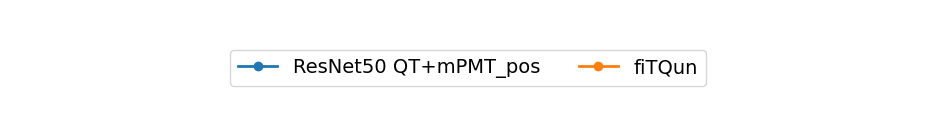

In [48]:
from matplotlib.ticker import MaxNLocator, LogLocator
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx] 


# instead of using the filtered muons list (from get quantities), im using all and then applying both the muon and the physical cuts as a selection filter (when binning) - therefore the baseline dimension is just the common events between h5 and fitqun

resnet_muon_position = WatChMaLPositionRegression(
    outdir_reg + output_pos,
    "ResNet50 QT+mPMT_pos",
    true_positions=data_new_geo["positions"][h5_keep_idx],
    true_directions=data_new_geo["directions"][h5_keep_idx],
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_mask_h5
)


fitqun_mu = FitQun1ParticleFit(
    fq,
    "fiTQun",
    true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
    true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
    true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
    true_labels=2,                        
    indices=fq_keep_idx[mu_mask_h5],       
    selection=None,
)


muon_mom_binning = [
    get_binning(data_new_geo["momentum"][h5_keep_idx], 20, 0, 1000),
    get_binning(data_new_geo["momentum"][h5_keep_idx][mu_mask_h5], 20, 0, 1000),
]

muon_cos_zenith_binning = [
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0]), 20, -1, 1),
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0][mu_mask_h5]), 20, -1, 1),
]

muon_azimuth_binning = [
    get_binning(data_new_geo["angles"][h5_keep_idx, 1] * 180 / np.pi, 20, -180, 180),
    get_binning(data_new_geo["angles"][h5_keep_idx, 1][mu_mask_h5] * 180 / np.pi, 20, -180, 180),
]

muon_dwall_binning = [
    get_binning(data_new_geo["dwall"][h5_keep_idx], 22, 50, 300),
    get_binning(data_new_geo["dwall"][h5_keep_idx][mu_mask_h5], 22, 50, 300),
]

muon_towall_binning = [
    get_binning(data_new_geo["towall"][h5_keep_idx], 30, 50, 800),
    get_binning(data_new_geo["towall"][h5_keep_idx][mu_mask_h5], 30, 50, 800),
]

all_runs_pos = [resnet_muon_position, fitqun_mu]

fig1, ax1 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_towall_binning[r],       
        ax=ax1,
        x_label="Distance to detector wall [cm]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax1.set_title("Muon 3D Position Resolution vs Distance to Wall", fontsize=16)
fig1.tight_layout()

handles, labels = ax1.get_legend_handles_labels()


fig2, ax2 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_dwall_binning[r],
        ax=ax2,
        x_label="Distance from detector wall [cm]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax2.set_title("Muon 3D Position Resolution vs Distance from Wall", fontsize=16)
fig2.tight_layout()

handles, labels = ax2.get_legend_handles_labels()

fig3, ax3 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_cos_zenith_binning[r],
        ax=ax3,
        x_label="Cosine of Zenith",
        y_label="Position resolution [cm]",
        legend=None
    )

ax3.set_title("Muon 3D Position Resolution vs Cosine of Zenith", fontsize=16)
fig3.tight_layout()

handles, labels = ax3.get_legend_handles_labels()


fig4, ax4 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_azimuth_binning[r],
        ax=ax4,
        x_label="Azimuth [°]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax4.set_title("Muon 3D Position Resolution vs Azimuth", fontsize=16)
fig4.tight_layout()

handles, labels = ax4.get_legend_handles_labels()


fig5, ax5 = plt.subplots(figsize=(10, 7))

for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        'position_3d_errors',
        muon_mom_binning[r],
        ax=ax5,
        x_label="True muon momentum [MeV]",
        y_label="Position resolution [cm]",
        legend=None
    )

ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax5.set_title("Muon 3D Position Resolution vs Momentum", fontsize=16)
fig5.tight_layout()

handles, labels = ax5.get_legend_handles_labels()

fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
ax_legend.axis('off')
ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
fig_legend.tight_layout()

plt.show()


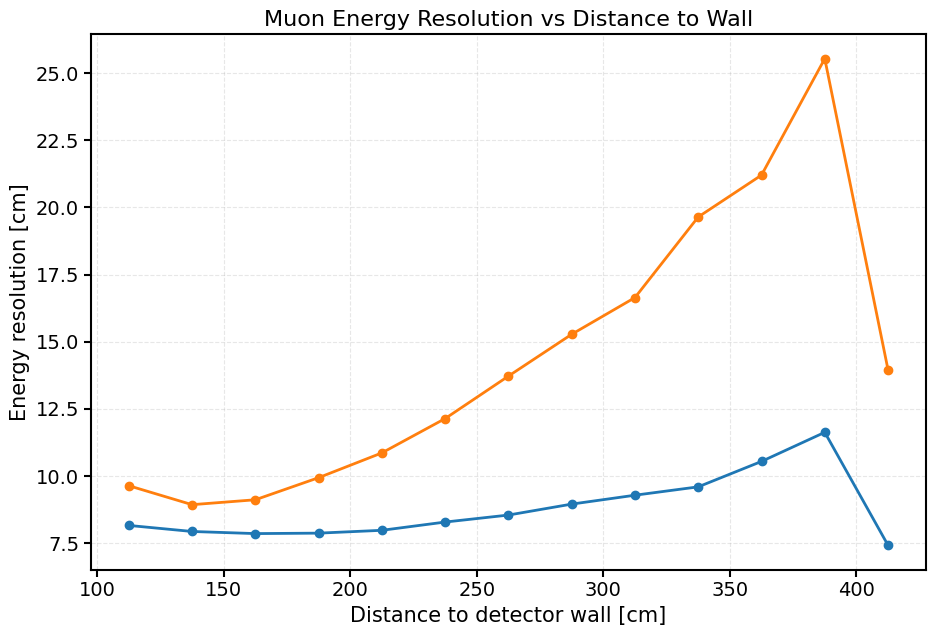

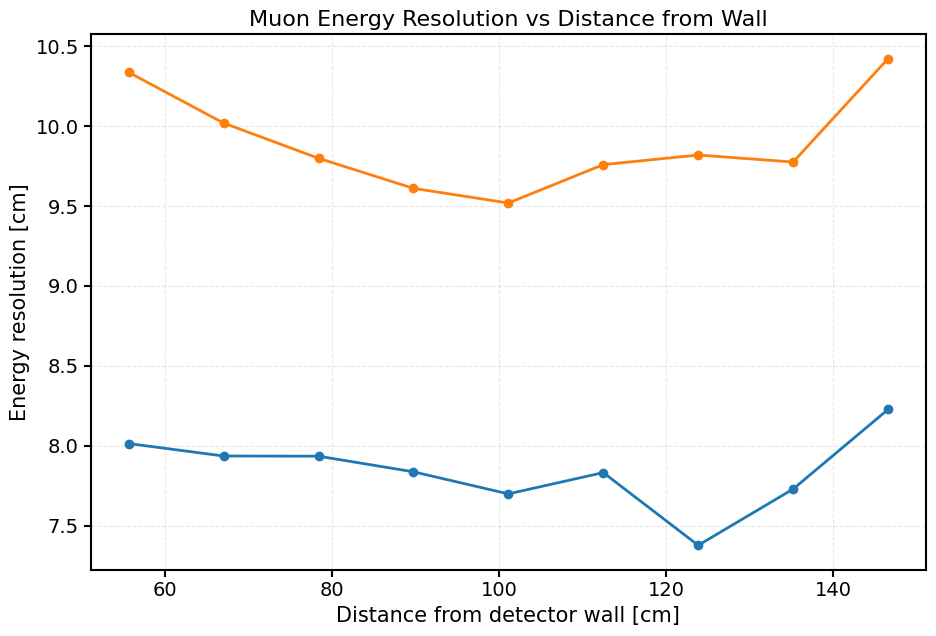

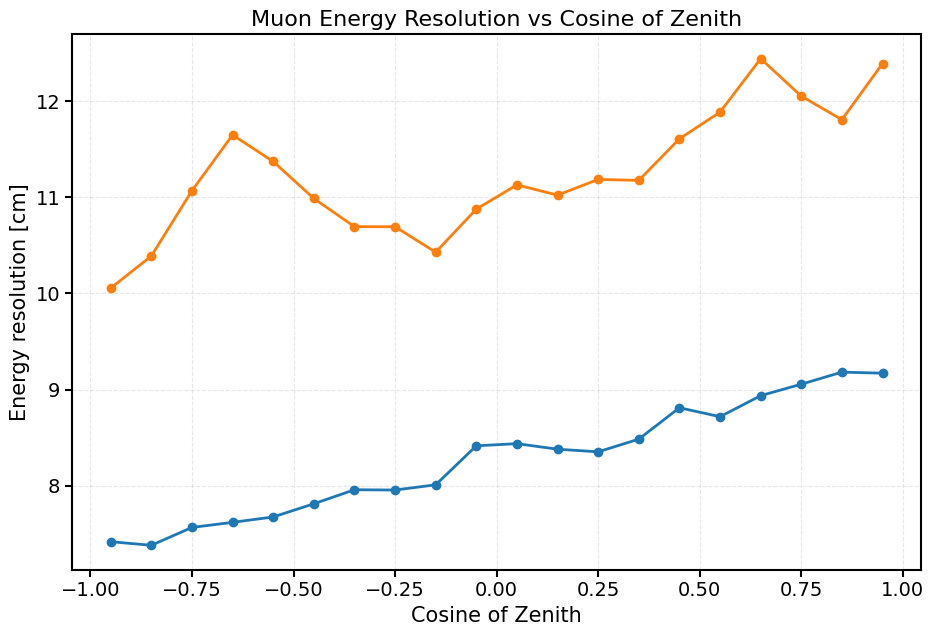

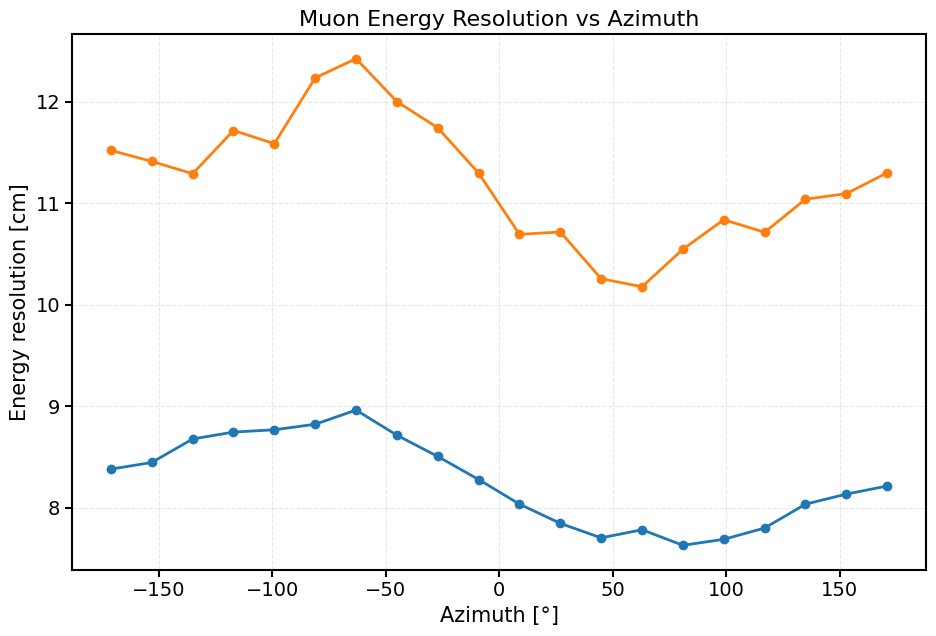

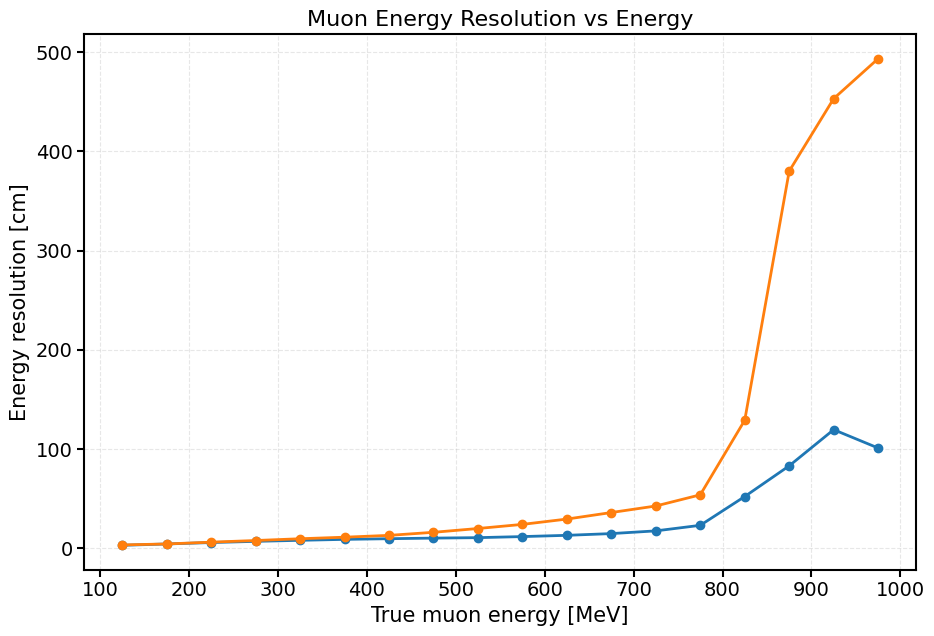

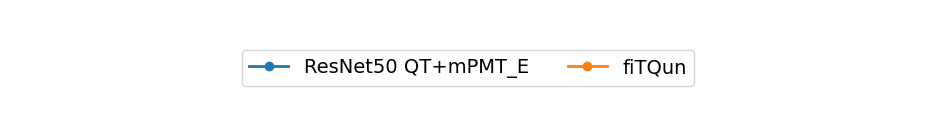

In [30]:

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
# mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx]

resnet_muon_energy = WatChMaLEnergyRegression(
    outdir_reg + output_energy,             
    "ResNet50 QT+mPMT_E",
    true_momenta=data_new_geo["momentum"][h5_keep_idx],   
    true_labels=labels,                                  
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_mask_h5
)

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
#     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
#     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
#     true_labels=2,
#     indices=fq_keep_idx[mu_mask_h5],
#     selection=None,
# )

all_runs_pos = [resnet_muon_energy, fitqun_mu]

fig1, ax1 = plt.subplots(figsize=(10, 7))
for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        "energy_residuals",
        muon_towall_binning[r],
        ax=ax1,
        x_label="Distance to detector wall [cm]",
        y_label="Energy resolution [cm]",
        legend=None
    )
ax1.set_title("Muon Energy Resolution vs Distance to Wall", fontsize=16)
fig1.tight_layout()
handles, labels = ax1.get_legend_handles_labels()

fig2, ax2 = plt.subplots(figsize=(10, 7))
for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        "energy_residuals",
        muon_dwall_binning[r],
        ax=ax2,
        x_label="Distance from detector wall [cm]",
        y_label="Energy resolution [cm]",
        legend=None
    )
ax2.set_title("Muon Energy Resolution vs Distance from Wall", fontsize=16)
fig2.tight_layout()
handles, labels = ax2.get_legend_handles_labels()

fig3, ax3 = plt.subplots(figsize=(10, 7))
for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        "energy_residuals",
        muon_cos_zenith_binning[r],
        ax=ax3,
        x_label="Cosine of Zenith",
        y_label="Energy resolution [cm]",
        legend=None
    )
ax3.set_title("Muon Energy Resolution vs Cosine of Zenith", fontsize=16)
fig3.tight_layout()
handles, labels = ax3.get_legend_handles_labels()

fig4, ax4 = plt.subplots(figsize=(10, 7))
for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        "energy_residuals",
        muon_azimuth_binning[r],
        ax=ax4,
        x_label="Azimuth [°]",
        y_label="Energy resolution [cm]",
        legend=None
    )
ax4.set_title("Muon Energy Resolution vs Azimuth", fontsize=16)
fig4.tight_layout()
handles, labels = ax4.get_legend_handles_labels()

fig5, ax5 = plt.subplots(figsize=(10, 7))
for r in range(len(all_runs_pos)):
    plot_resolution_profile(
        [all_runs_pos[r]],
        "energy_residuals",
        muon_mom_binning[r],
        ax=ax5,
        x_label="True muon energy [MeV]",
        y_label="Energy resolution [cm]",
        legend=None
    )
ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax5.set_title("Muon Energy Resolution vs Energy", fontsize=16)
fig5.tight_layout()
handles, labels = ax5.get_legend_handles_labels()

fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
ax_legend.axis('off')
ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
fig_legend.tight_layout()

plt.show()